# Point 3, Decision Support, Fixed Interval Policy

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. The Cost Model](#sec3)
- [4. The Fixed Policy](#sec4)
- [5. Checking Against Real Outcomes](#sec5)
- [6. Fairness Check](#sec6)
- [7. How Much Would These Numbers Move](#sec7)
- [8. Saving The Standardized Result](#sec8)
- [9. How Sensitive Is This To The Exact Cost Ratio](#sec9)
- [10. Takeaways](#sec10)

<a id="sec1"></a>

## 1. The Problem And This Approach

A memory clinic cannot bring every patient back for a full workup every week, that would be far too expensive, but it also cannot wait years between visits, because a patient can quietly cross from a healthy diagnosis into a worse one between two visits, and nobody notices until the damage is already done. Point 3 turns a risk score, RISK_SCORE below, into an actual scheduling decision, how many months should pass before this patient is checked again.

This notebook is the first of four ways this folder answers that question, one interval choosing policy per notebook, fixed, snapshot adaptive, trajectory adaptive, and forecast adaptive, each one reading more of what is already known about a patient than the last. The fixed policy uses none at all, every patient, regardless of their own risk, is checked every SAFE_INTERVAL_MONTHS months. It cannot be the cheapest policy on average, since it never adapts to anyone, but it is the simplest possible baseline, and the fairest one by construction, both properties worth having a real number for rather than assuming.

All interval notebooks in this folder, plus the risk factor notebooks, the fairness notebook, and the pipeline notebook that build on the same idea, are self sufficient, each one loads the data, fits or defines its own policy, and appends one standardized row per train and test split to results/decision_support/approach_comparison.csv. A separate notebook, comparison.ipynb, reads that shared file afterward and lines every approach up side by side, so this notebook can be read and rerun entirely on its own.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)


<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, the single table produced by merging Point 1's imaging derived measures with the clinical and diagnostic fields, one row per patient per visit, keyed by RID and the normalized visit code.

A handful of biomarker columns are not measured at every visit. HIPPO_NORM, ENTORHINAL_NORM, and AMYGDALA_NORM are volumes from Point 1's imaging pipeline, SUMMARY_SUVR and ABETA_RATIO come from the amyloid measurements, TAU and PTAU from the cerebrospinal fluid panel. forward_fill_by_patient carries each patient's most recently known value forward to their later visits, sorted by EXAMDATE_DX, so a visit without a fresh scan can still be scored using the last one that was taken, instead of being dropped outright for missing data.

`RISK_SCORE` now comes from point two's own real discrete time hazard estimator, built in `hazard_survival_model.ipynb`, following 05 pm, lesson 6, directly, structural MRI, amyloid PET, and cerebrospinal fluid together, fit on a genuine multi visit panel rather than one visit predicting only the very next one. That notebook already validates its own chosen estimator on held out patients, area under the ROC curve, a bootstrap confidence interval, and a sanity check against prior diagnosis group, so this notebook only ever reads its saved output, `results/hazard_model/hazard_estimates.csv`, merged in below by `RID` and by visit code.

Coverage is the real cost of that richer estimator. The cerebrospinal fluid markers its own richer feature tier needs are not measured at every visit, so only a bit over half of all rows end up with a genuine `HAZARD_ESTIMATE` this way. The cell below keeps this folder's own earlier fitted estimator too, a Logistic Regression on one hot `DIAGNOSIS` and `AMYLOID_STATUS` categories alone, fit against the same `DIAGNOSIS_WORSENED_NEXT` real outcome `compute_diagnosis_worsening` already provides, now purely as a fallback for whichever rows the richer estimator cannot reach, reported explicitly by coverage percent rather than silently filled in.

Both estimators, the richer one and the fallback, are fit or read only from the training patients below, then applied to every row in both splits, so this stays exactly as independent as before, nothing here reads a column another point in this project produces without that dependency being named directly. Everything downstream of it, the cost model, the policy, the fairness check, still only ever reads the `RISK_SCORE` column by name and does not care how its values were built.

Finally, subject_train_test_split holds out 25 percent of patients, by RID rather than by row, so the same patient's repeated visits never end up split across train and test, with random_state=42 fixed so every approach notebook in this folder, and hazard_survival_model.ipynb itself, trains and tests on exactly the same patients.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

data['DIAGNOSIS_MCI'] = (data['DIAGNOSIS'] == 2).astype(float)
data['DIAGNOSIS_DEMENTIA'] = (data['DIAGNOSIS'] == 3).astype(float)
data['AMYLOID_POSITIVE'] = (data['AMYLOID_STATUS'] == 1).astype(float)
data['AMYLOID_UNKNOWN'] = data['AMYLOID_STATUS'].isna().astype(float)
hazard_features = ['DIAGNOSIS_MCI', 'DIAGNOSIS_DEMENTIA', 'AMYLOID_POSITIVE', 'AMYLOID_UNKNOWN']

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

fallback_train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_train_data = fallback_train_outcomes[fallback_train_outcomes['HAS_NEXT_VISIT']]
fallback_test_data = fallback_test_outcomes[fallback_test_outcomes['HAS_NEXT_VISIT']]

fallback_model, fallback_scaler = du.fit_logistic_baseline(
    fallback_train_data[hazard_features],
    fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)
fallback_train_metrics = du.evaluate_classification(
    fallback_model, fallback_train_data[hazard_features], fallback_train_data['DIAGNOSIS_WORSENED_NEXT'], scaler=fallback_scaler,
)
fallback_test_metrics = du.evaluate_classification(
    fallback_model, fallback_test_data[hazard_features], fallback_test_data['DIAGNOSIS_WORSENED_NEXT'], scaler=fallback_scaler,
)
print(f'Fallback estimator, fit on {len(fallback_train_data)} training rows with a next visit on record')
print(f"Fallback estimator, train area under the ROC curve {fallback_train_metrics['auc']:.3f}, "
      f"test area under the ROC curve {fallback_test_metrics['auc']:.3f}")

train_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(train_df[hazard_features]))[:, 1]
test_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(test_df[hazard_features]))[:, 1]

# SWAP POINT: point two now exists, results/hazard_model/hazard_estimates.csv
# holds HAZARD_ESTIMATE from a real multi visit discrete time survival
# model, hazard_survival_model.ipynb, following 05 pm, lesson 6, directly,
# fit on structural MRI, amyloid PET, and cerebrospinal fluid together
# rather than on DIAGNOSIS and AMYLOID_STATUS alone. Coverage is not
# complete, so RISK_SCORE below takes HAZARD_ESTIMATE wherever it exists
# and keeps the fallback estimator above only for the rows it does not
# reach.
hazard_estimates_path = os.path.join('..', '..', '..', 'results', 'hazard_model', 'hazard_estimates.csv')
hazard_estimates = pd.read_csv(hazard_estimates_path)[['RID', 'VISCODE2_norm', 'HAZARD_ESTIMATE']]

train_df = train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
test_df = test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')

train_df['RISK_SCORE'] = train_df['HAZARD_ESTIMATE'].fillna(train_df['FALLBACK_RISK_SCORE'])
test_df['RISK_SCORE'] = test_df['HAZARD_ESTIMATE'].fillna(test_df['FALLBACK_RISK_SCORE'])

train_hazard_coverage = train_df['HAZARD_ESTIMATE'].notna().mean() * 100
test_hazard_coverage = test_df['HAZARD_ESTIMATE'].notna().mean() * 100
print(f'Train, {train_hazard_coverage:.1f} percent of rows use the richer survival based HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator above.')
print(f'Test,  {test_hazard_coverage:.1f} percent of rows use the richer survival based HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator above.')

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
Fallback estimator, fit on 7280 training rows with a next visit on record
Fallback estimator, train area under the ROC curve 0.694, test area under the ROC curve 0.676
Train, 52.6 percent of rows use the richer survival based HAZARD_ESTIMATE, the rest use the fallback estimator above.
Test,  54.0 percent of rows use the richer survival based HAZARD_ESTIMATE, the rest use the fallback estimator above.


<a id="sec3"></a>

## 3. The Cost Model

Every interval choice trades off two very different kinds of cost. CHECK_COST is what one routine check in visit costs, cheap, and paid every time regardless of what it finds. MISSED_CONVERSION_COST is what it costs to leave a patient unchecked for so long that a phase change is missed entirely and only caught much later, expensive, and only paid when the interval chosen turns out to have been too long for that particular patient. Neither number can be read off ADNI itself, CHECK_COST equal to 1 and a base MISSED_CONVERSION_COST equal to 20 are documented assumptions set once below, so a missed conversion for a patient already Cognitively Normal is treated as worth twenty routine checks, together with REFERENCE_INTERVAL_MONTHS, the interval a cost is measured against, and SAFE_INTERVAL_MONTHS, the fixed policy's own interval below.

A single missed conversion cost for every patient hides a real difference. Missing a Cognitively Normal patient's first move toward decline is not the same event as missing a further step down for a patient already diagnosed MCI or Dementia, in the second case there is already more ground to lose and less time to recover it. missed_conversion_cost_for scales the base MISSED_CONVERSION_COST by MCI_OR_WORSE_COST_MULTIPLIER, set to 2.8, for exactly those rows, a Cognitively Normal patient keeps the base cost of 20, an MCI or Dementia patient is priced at 56. The 2.8 figure is not invented for this notebook, a 2026 medRxiv preprint on the societal cost of Alzheimer's disease by diagnosis timing reports roughly 62000 euro per year for an early MCI patient against roughly 175000 euro per year for a late severe Alzheimer's patient, a ratio of about 2.8, used here as the closest available real cost anchor for how much more expensive a later stage missed conversion actually is.

That 2.8 figure is one point estimate from one source, not the only defensible number. A broader targeted literature review, Global Societal Burden of Alzheimer's Disease by Severity, published in Neurology and Therapy and covering 81 separate studies from 2013 to 2024, reports that societal cost typically rises by at least 50 percent between consecutive severity levels, with most studies placing the ratio between mild and severe disease somewhere between about 1.4 and 3.6 depending on which severity scale and which cost scope the underlying study used, and at least one study in the review reporting a fourfold difference. 2.8 sits inside that broader picture rather than at either edge of it, but the picture itself is wide enough that no single number in it should be presented as the settled one. Section 9 below reruns this notebook's own policy at 1.5, at 2.8, and at 4.0, the low end, the default, and the high end actually seen in this literature, so the reader can see directly which conclusions hold across the whole range and which ones depend on the exact multiplier chosen, rather than resting everything on 2.8 alone.

ConversionCostModel follows util.RULCostModel's calling convention from 04-rul, but here the same instantiate once and call .cost as many times pattern is wrapped in cost_model_for, since missed_conversion_cost is now a value that depends on each row's own DIAGNOSIS rather than one fixed number, cost_model_for builds a fresh model scoped to whichever dataframe is passed in, always with rows in the same order the caller will use for rid_ids and risk_scores right after. Every interval policy notebook in this folder uses the same CHECK_COST, base MISSED_CONVERSION_COST, and MCI_OR_WORSE_COST_MULTIPLIER, so a total cost reported here means exactly the same thing as a total cost reported in the other two that price a candidate interval with ConversionCostModel.cost the same way this notebook does. 4_forecast_adaptive.ipynb is a fourth interval policy notebook in this folder sharing these same three constants, but pricing its own policy with ConversionCostModel.cost_from_forecast instead, so its own total_cost is not on this same scale, see comparison.ipynb section 3 for why.

missed_conversion_cost_for and cost_model_for below are now thin, notebook local wrappers around du.stratified_missed_conversion_cost and du.cost_model_for in util/decision_util.py, where the stratification and the citation above actually live once, so a future notebook that needs the same stratified cost only has to import decision_util and call them, not redefine them again.

In [3]:
CHECK_COST = 1.0
MISSED_CONVERSION_COST = 20.0
MCI_OR_WORSE_COST_MULTIPLIER = 2.8
REFERENCE_INTERVAL_MONTHS = 12.0
SAFE_INTERVAL_MONTHS = 6

def missed_conversion_cost_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.stratified_missed_conversion_cost(
        df, MISSED_CONVERSION_COST, multiplier,
    )

def cost_model_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.cost_model_for(
        df, CHECK_COST, MISSED_CONVERSION_COST, multiplier,
        safe_interval_months=SAFE_INTERVAL_MONTHS,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )


<a id="sec4"></a>

## 4. The Fixed Policy

The policy itself is one sentence, every patient is checked every SAFE_INTERVAL_MONTHS months, six per the cell above, whatever their own RISK_SCORE happens to be. There is no model to fit and no per patient recommendation array to build, cmodel.cost defaults its interval_months argument to the cost model's own safe_interval_months whenever none is given, which already is this policy, so evaluate_fixed_policy below only has to call .cost once per split, with threshold=0.5 marking which rows count as over threshold, and read off the total cost and that count.

Run separately on train and then test below, since even a policy with nothing to fit is still worth checking on data it was not looked at first, if the two totals move together in proportion to their row counts that says the split itself, not any fitting, is driving the result.

In [4]:
def evaluate_fixed_policy(df, label):
    total_cost, over_threshold_count, _ = cost_model_for(df).cost(
        rid_ids=df['RID'].values,
        risk_scores=df['RISK_SCORE'].values,
        threshold=0.5,
        return_margin=False,
    )
    print(f'{label}, {len(df)} rows')
    print(f'  Fixed policy, total cost {total_cost:9.1f}, rows over threshold {over_threshold_count}')
    return total_cost, over_threshold_count

train_total_cost, train_over_threshold = evaluate_fixed_policy(train_df, 'Train')
test_total_cost, test_over_threshold = evaluate_fixed_policy(test_df, 'Test')


Train, 10162 rows
  Fixed policy, total cost   59987.6, rows over threshold 926
Test, 3665 rows
  Fixed policy, total cost   22479.4, rows over threshold 387


**Where that cost is actually going.** The total cost above is one number for the whole split, it hides how unevenly it is earned. RISK_SCORE now blends a continuous survival based estimate for a bit over half of all rows with a small, fixed set of fallback values for the rest, so grouping by its own exact value no longer makes sense the way it once did under the fallback estimator alone. The chart below instead groups rows into ten roughly equal sized risk level bins, and regroups the same cost the cell above already computes, split into its two terms, routine check cost, flat for every patient since the interval never changes, and expected missed conversion cost, which rises with mean RISK_SCORE even though the interval does not, one bar per bin, annotated with how many rows actually sit in it.

RISK_SCORE is grouped into 10 risk level bins of roughly equal size below, since the richer estimator now gives a continuous spread for most rows rather than one value per DIAGNOSIS times AMYLOID_STATUS combination, each bin priced with its own average missed conversion cost across whichever DIAGNOSIS values actually land in it.


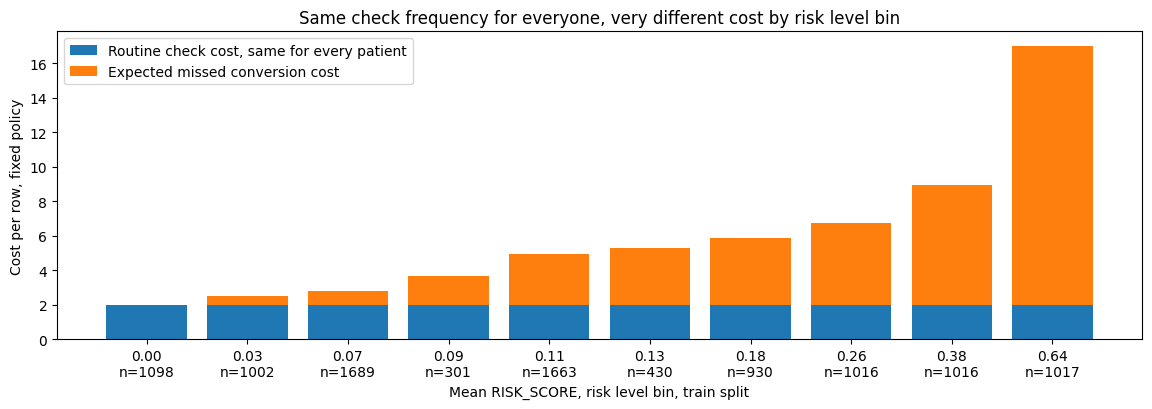

,risk_bin,mean_risk_score,n_rows,mean_diagnosis,routine_cost,missed_conversion_cost
0,"(-0.0008550000000000001, 0.000423]",0.000419,1098,3.000000,2.0,0.011726
1,"(0.000423, 0.0386]",0.025756,1002,1.709581,2.0,0.495384
2,"(0.0386, 0.073]",0.068209,1689,1.123742,2.0,0.825291
3,"(0.073, 0.0995]",0.092110,301,1.528239,2.0,1.659203
4,"(0.0995, 0.105]",0.105074,1663,2.004811,2.0,2.939803
5,"(0.105, 0.141]",0.129720,430,2.090698,2.0,3.311773
6,"(0.141, 0.224]",0.184900,930,1.898925,2.0,3.899600
7,"(0.224, 0.307]",0.264756,1016,1.505906,2.0,4.767686
8,"(0.307, 0.472]",0.376462,1016,1.524606,2.0,6.939349
9,"(0.472, 0.892]",0.643190,1017,1.894789,2.0,14.992595


In [5]:
def cost_breakdown_by_risk_level(df, n_bins=10):
    risk_bins = pd.qcut(df['RISK_SCORE'], q=n_bins, duplicates='drop')
    rows = []
    for level, level_df in df.groupby(risk_bins, observed=True):
        routine = (12.0 / SAFE_INTERVAL_MONTHS) * CHECK_COST
        mean_risk = level_df['RISK_SCORE'].mean()
        scaled_risk = mean_risk * (SAFE_INTERVAL_MONTHS / REFERENCE_INTERVAL_MONTHS)
        mean_missed_conversion_cost = missed_conversion_cost_for(level_df).mean()
        missed = scaled_risk * mean_missed_conversion_cost
        rows.append({
            'risk_bin': str(level),
            'mean_risk_score': mean_risk,
            'n_rows': len(level_df),
            'mean_diagnosis': level_df['DIAGNOSIS'].mean(),
            'routine_cost': routine,
            'missed_conversion_cost': missed,
        })
    return pd.DataFrame(rows).sort_values('mean_risk_score').reset_index(drop=True)

breakdown = cost_breakdown_by_risk_level(train_df)
print(f'RISK_SCORE is grouped into {len(breakdown)} risk level bins of roughly equal size below, '
      f'since the richer estimator now gives a continuous spread for most rows rather than one '
      f'value per DIAGNOSIS times AMYLOID_STATUS combination, each bin priced with its own average '
      f'missed conversion cost across whichever DIAGNOSIS values actually land in it.')

plt.figure(figsize=figsize)
x = np.arange(len(breakdown))
plt.bar(x, breakdown['routine_cost'], label='Routine check cost, same for every patient')
plt.bar(x, breakdown['missed_conversion_cost'], bottom=breakdown['routine_cost'],
        label='Expected missed conversion cost')
plt.xticks(x, [f'{v:.2f}\nn={n}' for v, n in zip(breakdown['mean_risk_score'], breakdown['n_rows'])])
plt.xlabel('Mean RISK_SCORE, risk level bin, train split')
plt.ylabel('Cost per row, fixed policy')
plt.title('Same check frequency for everyone, very different cost by risk level bin')
plt.legend()
plt.show()
breakdown

<a id="sec5"></a>

## 5. Checking Against Real Outcomes

Every number so far, total cost, the cost breakdown by risk level, is a function of the cost formula and RISK_SCORE alone, nothing yet has checked what actually happened to a real patient outside of the training rows the hazard estimator above already fit on. final.csv already records DIAGNOSIS at every visit, so compute_diagnosis_worsening below finds, for every row, that same patient's next real recorded visit and whether DIAGNOSIS was numerically worse there, a real worsening event, checked here directly against the fixed interval, section 4 above never reads this DIAGNOSIS_WORSENED_NEXT column at all, only RISK_SCORE and the fixed interval it is compared to. The hazard estimator that built RISK_SCORE was fit only on training patients, so the check below is a genuinely held out one on the test split, on train the same rows are being checked against an estimator that already saw their own outcome while fitting, exactly why the two splits are read separately below rather than pooled into one number.

For every row with a real worsening event, the margin below is the real gap in months to that next visit minus the interval this fixed policy would have recommended, six months regardless of the patient. A positive margin means a check on this policy's own schedule would have happened at or before the real worsening was ever observed, caught in time, a negative one means the policy's schedule would have left the patient unchecked for longer than the real world actually took to reveal it.

This is retrospective, not a true counterfactual, ADNI's actual visit spacing was never governed by this or any other policy under test here, and it should be read together with the total cost above, not in isolation, since a policy that always recommended the shortest possible interval would trivially win this check alone while being far too expensive to ever deploy.

Train, 501 rows with a real worsening event before the next recorded visit, 87.6 percent would have been caught by this policy in time.
Test, 197 rows with a real worsening event before the next recorded visit, 90.9 percent would have been caught by this policy in time.


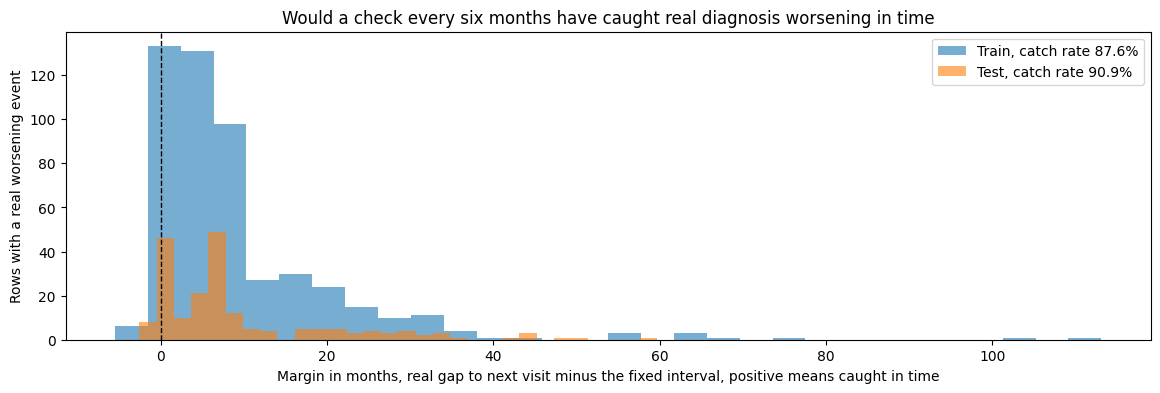

In [6]:
def catch_rate_report(df, label, recommended):
    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch_rate = (margin >= 0).mean() * 100
    print(f'{label}, {worsened.sum()} rows with a real worsening event before the next recorded visit, '
          f'{catch_rate:.1f} percent would have been caught by this policy in time.')
    return margin, catch_rate

train_margin, train_catch_rate = catch_rate_report(
    train_df, 'Train', np.full(len(train_df), SAFE_INTERVAL_MONTHS),
)
test_margin, test_catch_rate = catch_rate_report(
    test_df, 'Test', np.full(len(test_df), SAFE_INTERVAL_MONTHS),
)

plt.figure(figsize=figsize)
plt.hist(train_margin, bins=30, alpha=0.6, label=f'Train, catch rate {train_catch_rate:.1f}%')
plt.hist(test_margin, bins=30, alpha=0.6, label=f'Test, catch rate {test_catch_rate:.1f}%')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Margin in months, real gap to next visit minus the fixed interval, positive means caught in time')
plt.ylabel('Rows with a real worsening event')
plt.title('Would a check every six months have caught real diagnosis worsening in time')
plt.legend()
plt.show()

<a id="sec6"></a>

## 6. Fairness Check

DIDI, the Disparate Impact Discrimination Index from 07-ciml, lesson 1, measures how much a recommendation differs on average between a protected group and the rest, summed over every protected attribute checked, here PTGENDER, a bucketed PTEDUCAT, and PTMARRY. A DIDI of 0 means the recommendation is identical on average across every group checked.

Here the recommended interval array is constant, every patient gets the same SAFE_INTERVAL_MONTHS, so DIDI is 0 by construction, before the formula is even run. It is still computed rather than assumed, both as a check on the formula itself against a known answer, and because it is the honest, and informative, reason the fixed policy is the fairest of the four interval policies in this folder, it simply never looks at anything that could make it unfair, not RISK_SCORE and not any protected attribute either.

In [7]:
def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

train_df = train_df.copy()
test_df = test_df.copy()
train_df['PTEDUCAT_BUCKET'] = du.bucket_educat(train_df['PTEDUCAT'], split_at=16)
test_df['PTEDUCAT_BUCKET'] = du.bucket_educat(test_df['PTEDUCAT'], split_at=16)

train_df['RECOMMENDED_INTERVAL'] = SAFE_INTERVAL_MONTHS
test_df['RECOMMENDED_INTERVAL'] = SAFE_INTERVAL_MONTHS

train_didi = du.compute_didi(train_df, train_df['RECOMMENDED_INTERVAL'].values, make_protected(train_df))
test_didi = du.compute_didi(test_df, test_df['RECOMMENDED_INTERVAL'].values, make_protected(test_df))
print(f'DIDI on the fixed recommendation, train: {train_didi:.3f}')
print(f'DIDI on the fixed recommendation, test:  {test_didi:.3f}')


DIDI on the fixed recommendation, train: 0.000
DIDI on the fixed recommendation, test:  0.000


<a id="sec7"></a>

## 7. How Much Would These Numbers Move

Every number above, total cost, DIDI, catch rate, comes from one fixed sample of patients, the actual train and test split. A different, equally valid sample of ADNI patients would give a slightly different number, bootstrap_ci below answers by how much, resample patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, recompute the same metric on each resample, and read the 2.5th and 97.5th percentile as a 95 percent interval. The histograms below are the full bootstrap distribution behind each interval, not only its two endpoints.

Wide or narrow, this interval says nothing about whether the number is good, only how much of it is signal against a different sample versus noise from this particular one, useful together with the comparison against the other three policies, not instead of it.

Train, total cost 59987.6, 95% CI [57020.6, 63167.5]
Test,  total cost 22479.4, 95% CI [20564.3, 24437.0]
Train, catch rate 87.6%, 95% CI [84.5, 90.4]
Test,  catch rate 90.9%, 95% CI [86.7, 94.8]


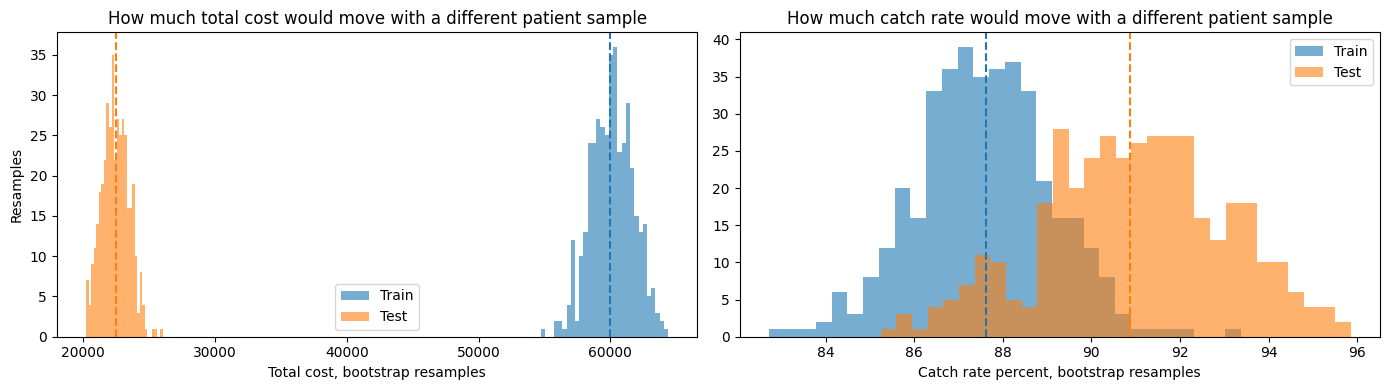

In [8]:
def cost_metric(d):
    total_cost, _, _ = cost_model_for(d).cost(
        rid_ids=d['RID'].values, risk_scores=d['RISK_SCORE'].values,
        threshold=0.5, return_margin=False,
    )
    return total_cost

def didi_metric(d):
    d = d.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    recommended = np.full(len(d), SAFE_INTERVAL_MONTHS)
    return du.compute_didi(d, recommended, make_protected(d))

def catch_rate_metric(d):
    outcomes = du.compute_diagnosis_worsening(d, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = np.full(len(outcomes), SAFE_INTERVAL_MONTHS)
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    return (margin >= 0).mean() * 100

train_cost_point, train_cost_lo, train_cost_hi, train_cost_samples = du.bootstrap_ci(train_df, cost_metric, id_col='RID')
test_cost_point, test_cost_lo, test_cost_hi, test_cost_samples = du.bootstrap_ci(test_df, cost_metric, id_col='RID')
train_didi_point, train_didi_lo, train_didi_hi, _ = du.bootstrap_ci(train_df, didi_metric, id_col='RID')
test_didi_point, test_didi_lo, test_didi_hi, _ = du.bootstrap_ci(test_df, didi_metric, id_col='RID')
train_catch_point, train_catch_lo, train_catch_hi, train_catch_samples = du.bootstrap_ci(train_df, catch_rate_metric, id_col='RID')
test_catch_point, test_catch_lo, test_catch_hi, test_catch_samples = du.bootstrap_ci(test_df, catch_rate_metric, id_col='RID')

print(f'Train, total cost {train_cost_point:.1f}, 95% CI [{train_cost_lo:.1f}, {train_cost_hi:.1f}]')
print(f'Test,  total cost {test_cost_point:.1f}, 95% CI [{test_cost_lo:.1f}, {test_cost_hi:.1f}]')
print(f'Train, catch rate {train_catch_point:.1f}%, 95% CI [{train_catch_lo:.1f}, {train_catch_hi:.1f}]')
print(f'Test,  catch rate {test_catch_point:.1f}%, 95% CI [{test_catch_lo:.1f}, {test_catch_hi:.1f}]')

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(train_cost_samples, bins=30, alpha=0.6, label='Train')
axes[0].hist(test_cost_samples, bins=30, alpha=0.6, label='Test')
axes[0].axvline(train_cost_point, color='C0', linestyle='--')
axes[0].axvline(test_cost_point, color='C1', linestyle='--')
axes[0].set_xlabel('Total cost, bootstrap resamples')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much total cost would move with a different patient sample')
axes[0].legend()

axes[1].hist(train_catch_samples, bins=30, alpha=0.6, label='Train')
axes[1].hist(test_catch_samples, bins=30, alpha=0.6, label='Test')
axes[1].axvline(train_catch_point, color='C0', linestyle='--')
axes[1].axvline(test_catch_point, color='C1', linestyle='--')
axes[1].set_xlabel('Catch rate percent, bootstrap resamples')
axes[1].set_title('How much catch rate would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec8"></a>

## 8. Saving The Standardized Result

One row per split, appended to the shared results/decision_support/approach_comparison.csv, read later by comparison.ipynb alongside the other approaches. append_approach_result is idempotent per approach and split, rerunning this notebook replaces its own two rows rather than piling up duplicates. The confidence intervals from the section above ride along in the same row.

In [9]:
du.append_approach_result(
    results_path, approach='fixed_policy', approach_group='interval_policy',
    split='train', n_rows=len(train_df), total_cost=train_total_cost,
    over_threshold_count=train_over_threshold, didi=train_didi,
    catch_rate=train_catch_rate,
    ci={
        'total_cost': (train_cost_lo, train_cost_hi),
        'didi': (train_didi_lo, train_didi_hi),
        'catch_rate': (train_catch_lo, train_catch_hi),
    },
    notes='No patient information used, same interval for everyone, DIDI is 0 by construction.',
)
result_row = du.append_approach_result(
    results_path, approach='fixed_policy', approach_group='interval_policy',
    split='test', n_rows=len(test_df), total_cost=test_total_cost,
    over_threshold_count=test_over_threshold, didi=test_didi,
    catch_rate=test_catch_rate,
    ci={
        'total_cost': (test_cost_lo, test_cost_hi),
        'didi': (test_didi_lo, test_didi_hi),
        'catch_rate': (test_catch_lo, test_catch_hi),
    },
    notes='No patient information used, same interval for everyone, DIDI is 0 by construction.',
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
8,hazard_logistic_core,hazard_model,train,6415,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, logistic, core..."
9,hazard_logistic_core,hazard_model,test,2291,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704754,0.782472,"Discrete time hazard estimator, logistic, core..."


<a id="sec9"></a>

## 9. How Sensitive Is This To The Exact Cost Ratio

Section 3 already flagged that MCI_OR_WORSE_COST_MULTIPLIER, set to 2.8, is a single point estimate sitting inside a documented range that runs from about 1.4 to about 4 depending on the study. This section checks what actually changes about the fixed policy's own numbers if that multiplier had been set at either end of the range instead of at its center.

The fixed policy never looks at DIAGNOSIS or at cost to make its own scheduling decision, every patient gets SAFE_INTERVAL_MONTHS regardless, so catch_rate from section 5 above cannot move at all, only total_cost can, a more expensive missed conversion for the same MCI or Dementia patients raises the price of the same mistakes without changing which mistakes get made. Total cost is recomputed below at 1.5, at 2.8, and at 4.0, holding every other setting fixed, and the result is saved to cost_sensitivity_fixed_policy.csv for comparison.ipynb to read alongside the other three policies.

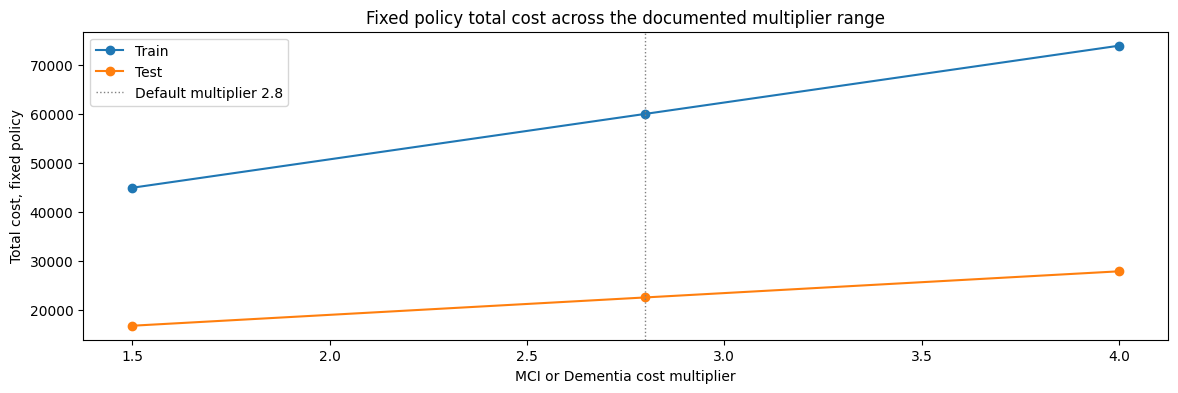

Catch rate stays at 87.6% train, 90.9% test across every multiplier tried here, the fixed policy never looks at DIAGNOSIS or at cost when it makes its own scheduling decision, so changing how much a missed conversion costs cannot change which patients get caught in time, only how expensive the ones it misses turns out to be.


,multiplier,approach,train_total_cost,test_total_cost,train_catch_rate,test_catch_rate
0,1.5,fixed_policy,44899.753307,16698.822882,87.62475,90.862944
1,2.8,fixed_policy,59987.590101,22479.361175,87.62475,90.862944
2,4.0,fixed_policy,73914.824064,27815.242676,87.62475,90.862944


In [10]:
SENSITIVITY_MULTIPLIERS = (1.5, 2.8, 4.0)

def total_cost_at(df, multiplier):
    total_cost, _, _ = cost_model_for(df, multiplier=multiplier).cost(
        rid_ids=df['RID'].values,
        risk_scores=df['RISK_SCORE'].values,
        threshold=0.5,
        return_margin=False,
    )
    return total_cost

sensitivity_rows = []
for multiplier in SENSITIVITY_MULTIPLIERS:
    sensitivity_rows.append({
        'multiplier': multiplier,
        'approach': 'fixed_policy',
        'train_total_cost': total_cost_at(train_df, multiplier),
        'test_total_cost': total_cost_at(test_df, multiplier),
        'train_catch_rate': train_catch_rate,
        'test_catch_rate': test_catch_rate,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(os.path.join(results_path, 'cost_sensitivity_fixed_policy.csv'), index=False)

plt.figure(figsize=figsize)
plt.plot(sensitivity_df['multiplier'], sensitivity_df['train_total_cost'], marker='o', label='Train')
plt.plot(sensitivity_df['multiplier'], sensitivity_df['test_total_cost'], marker='o', label='Test')
plt.axvline(MCI_OR_WORSE_COST_MULTIPLIER, color='gray', linestyle=':', linewidth=1,
            label=f'Default multiplier {MCI_OR_WORSE_COST_MULTIPLIER}')
plt.xlabel('MCI or Dementia cost multiplier')
plt.ylabel('Total cost, fixed policy')
plt.title('Fixed policy total cost across the documented multiplier range')
plt.legend()
plt.show()

print(f'Catch rate stays at {train_catch_rate:.1f}% train, {test_catch_rate:.1f}% test across every '
      f'multiplier tried here, the fixed policy never looks at DIAGNOSIS or at cost when it makes its '
      f'own scheduling decision, so changing how much a missed conversion costs cannot change which '
      f'patients get caught in time, only how expensive the ones it misses turns out to be.')

sensitivity_df

<a id="sec10"></a>

## 10. Takeaways

**Read this notebook's own numbers above as this approach's result on its own.** Cheapest to explain and to implement, and fair by construction, since it never looks at any patient information at all. See comparison.ipynb for how it stacks up against the other three interval policies, that side by side comparison is deliberately kept out of this notebook so it stays correct even if this notebook is rerun on its own later, with different cost parameters or a different biomarker set.